# Análisis de la representación de los streamlines en coordenadas polares

# ¿Porqué polares? 
En el análisis de streamlines 3D, las coordenadas `(x, y ,z)` son sensibles a traslaciones, rotaciones y pequeñas perturbaciones locales. Esto complica que una red neuronal aprenda petrones geométricos relevantes, ya que tendría que aprender a ignorar trasformaciones espaciales relevantes. Para resolver esto, se implementará una representación basada en coordenadas polares normlalizadas: $$[r_{\text{norm}}​,cos\theta,sin\theta,cosϕ,sinϕ]$$
donde:
* $r_\text{norm}$ es la distancia radial normalizada al centro de masa.
* $\theta$ es el ángulo polar (respecto al eje vertical)
* $\phi$ es el ángulo azimutal en el plano XY.
* Los ángulos se codifican con sen/cos para evitar discontinuidades y saltos angulares.

Esta representación permite desacoplar magnitud y orientación y proporciona invarianza y robustez frente a trasformaciones geométricas.

# Procedimiento experimental
Para evaluar la robustez de la respresentación polar, se han realizado tres experimentos principales usando streamlines sintéticas:
## Traslación
Se traslada la estreamline  el centro de masa por un vector arbitrario. Posteriormente se calcula el cambio medio L2 en las coordenadas euclideanas y las polares. Los resultados son:
* Distancias euclideanas cambian drásticamente: ~12.67
* Coordenadas polares normalizadas cambian prácticamente cero: ~4.6e-16.
**La representación es invariante a las traslaciones, eliminando la dependencia de la posición absoluta**

## Rotación alrededor del eje Z
Se ha rotado la streamline y el centor de masa alrededor del eje Z 30º (y también se ha probado otras rotaciones sobre ejes X e Y de manera gráfica). Se comparó el cambio medio L2 por feature (r, theta, phi). Los resultados obtenidos:
* `r` permanece prácticamente constante: la distancia radial no se altera por rotación.
* $\theta$ también se mantiene estable: orientación vertical no cambia al rotar el eje Z.
* $\phi$ cambia proporcionalmente al ángulo de rotación.
El encoding **desacopla magnitud y orientación**. Además, los experimentos sobre los ejes X e Y muestras cambios suaves y contunuos en theta y phi, confirmando que la representación es coherente para cualquier eje de rotación.

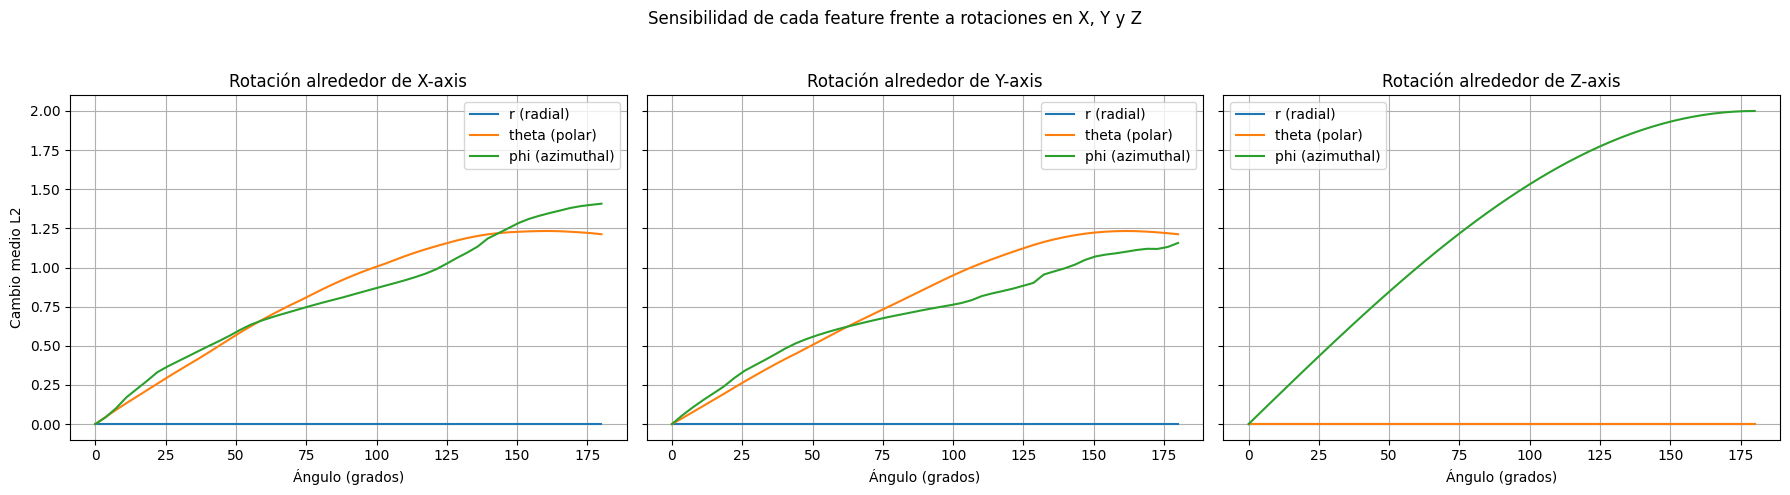

## Perturbaciones locales / curvatura
Se ha añadido ruido Gaussiano a cada punto de la streamline, simulando pequeñas perturbaciones locales. Los resultados dicen que:
* Los cambios en las features polares son menores que `(x, y, z)`.
* `r` apenas cambia, `theta` y `phi` cambian suavemente y proporcionalmente al ruido.
* La codificación sin/cos evita saltos angulares y discontinuidades.

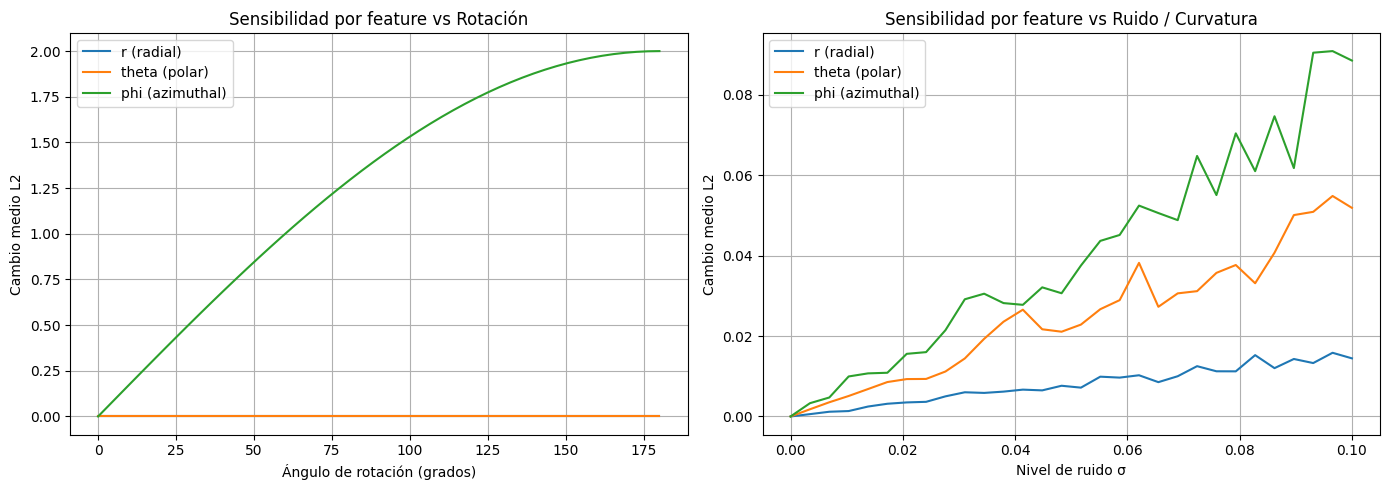

## Funciones auxiliares

In [7]:
import numpy as np 
import nibabel as nib

def process_single_streamline(streamline, global_com, r_min, r_max, epsilon=1e-6):
    centered_streamline = streamline - global_com

    r = np.linalg.norm(centered_streamline, axis=1)
    r_normalized = (r - r_min) / (r_max - r_min + epsilon)

    theta = np.arccos(np.clip(centered_streamline[:, 2] / (r + epsilon), -1, 1))
    theta_cos = np.cos(theta)
    theta_sin = np.sin(theta)

    phi = np.arctan2(centered_streamline[:, 1], centered_streamline[:, 0])
    phi_cos = np.cos(phi)
    phi_sin = np.sin(phi)

    return np.stack(
        (r_normalized, theta_cos, theta_sin, phi_cos, phi_sin),
        axis=1
    )

def compute_com(mri: nib.Nifti1Image) -> np.ndarray:
    """Compute center of mass of a Nifti image"""
    mri = nib.as_closest_canonical(mri)
    mri_data = mri.get_fdata()
    affine = mri.affine

    com_vox = center_of_mass(mri_data>0)
    com_ras = np.dot(affine, np.append(com_vox, 1))[:3]
        
    return com_ras

In [8]:
def add_local_noise(streamline, noise_std=0.05):
    noise = np.random.normal(scale=noise_std, size=streamline.shape)
    return streamline + noise

In [9]:
def rotate_z(points, angle_rad):
    R = np.array([
        [np.cos(angle_rad), -np.sin(angle_rad), 0],
        [np.sin(angle_rad),  np.cos(angle_rad), 0],
        [0, 0, 1]
    ])
    return points @ R.T

def rotate_x(points, angle_rad):
    R = np.array([
        [1, 0, 0],
        [0, np.cos(angle_rad), -np.sin(angle_rad)],
        [0, np.sin(angle_rad),  np.cos(angle_rad)]
    ])
    return points @ R.T

def rotate_y(points, angle_rad):
    R = np.array([
        [ np.cos(angle_rad), 0, np.sin(angle_rad)],
        [0, 1, 0],
        [-np.sin(angle_rad), 0, np.cos(angle_rad)]
    ])
    return points @ R.T

In [10]:
def mean_l2(a, b):
    return np.mean(np.linalg.norm(a - b, axis=1))


def feature_wise_l2(feat_a, feat_b):
    """
    Devuelve L2 medio por grupo de features:
    r, theta, phi
    """
    diff = feat_a - feat_b

    r_diff = np.mean(np.abs(diff[:, 0]))  # r_normalized

    theta_diff = np.mean(
        np.linalg.norm(diff[:, 1:3], axis=1)  # cosθ, sinθ
    )

    phi_diff = np.mean(
        np.linalg.norm(diff[:, 3:5], axis=1)  # cosφ, sinφ
    )

    return r_diff, theta_diff, phi_diff

## Datos

In [18]:
from dipy.io.streamline import load_tractogram
from pathlib import Path
import numpy as np

DUMMY_PATH = Path("/home/blancolote/TFM/Tractoinferno/ds003900-download/derivatives/testset/sub-1006/anat/sub-1006__T1w.nii.gz")
tractography_dir = Path("/home/blancolote/TFM/Tractoinferno/ds003900-download/derivatives/testset/sub-1006/tractography/")

trk_files = list(tractography_dir.glob("*.trk"))

streamlines_list = []

for file in trk_files:
    sft = load_tractogram(str(file), str(DUMMY_PATH))
    all_streamlines = sft.streamlines

    n_available = len(all_streamlines)
    n_sample = min(8, n_available)  # avoid sampling more than available

    random_indices = np.random.choice(n_available, size=n_sample, replace=False)

    for idx in random_indices:
        fiber = all_streamlines[idx]          # shape (N, 3)
        streamlines_list.append(fiber)

global_com = np.array([-0.15490368116425657, -4.5810723474444615, 24.506070862635717])
r_min = 4.988251983875604
r_max = 89.91602214736346


In [19]:
print(len(streamlines_list))

208


## Traslation analysis

In [22]:
import numpy as np

# ---------- 3 Random Translations ----------
rng = np.random.default_rng(seed=42)
translations = rng.uniform(-20.0, 20.0, size=(3, 3))  # shape (3, 3): 3 translations × (x, y, z)

# ---------- Streamlines to evaluate (add more as needed) ----------
streamlines = streamlines_list  # extend this list with your actual streamlines

# ---------- Storage ----------
xyz_diffs_original  = []   # L2 per (streamline, translation) in XYZ
feat_diffs_original = []   # L2 per (streamline, translation) in spherical

for sl in streamlines:
    for translation in translations:
        sl_translated         = sl + translation
        global_com_translated = global_com + translation

        # XYZ representation
        xyz_diff = mean_l2(sl, sl_translated)
        xyz_diffs_original.append(xyz_diff)

        # Spherical representation
        feat_original   = process_single_streamline(sl, global_com, r_min, r_max)
        feat_translated = process_single_streamline(sl_translated, global_com_translated, r_min, r_max)
        feat_diff       = mean_l2(feat_original, feat_translated)
        feat_diffs_original.append(feat_diff)

# ---------- Means ----------
mean_xyz_diff  = np.mean(xyz_diffs_original)
mean_feat_diff = np.mean(feat_diffs_original)

print(f"Translations used:\n{translations}\n")
print(f"L2 per (streamline × translation) — XYZ:       {xyz_diffs_original}")
print(f"L2 per (streamline × translation) — Spherical: {feat_diffs_original}")
print(f"\nMean L2 traslación usando (x,y,z):             {mean_xyz_diff:.6f}")
print(f"Mean L2 traslación usando tu representación:   {mean_feat_diff:.6f}")

Translations used:
[[ 10.95824194  -2.44486241  14.3439168 ]
 [  7.89472116 -16.23290608  19.02489407]
 [ 10.44558808  11.44257221 -14.87545469]]

L2 per (streamline × translation) — XYZ:       [np.float64(18.215607805716985), np.float64(26.225568752307588), np.float64(21.478405933810834), np.float64(18.21560780571699), np.float64(26.225568752307588), np.float64(21.478405933810837), np.float64(18.215607805716985), np.float64(26.225568752307584), np.float64(21.478405933810834), np.float64(18.215607805716992), np.float64(26.225568752307588), np.float64(21.47840593381084), np.float64(18.21560780571699), np.float64(26.225568752307584), np.float64(21.478405933810834), np.float64(18.21560780571699), np.float64(26.225568752307588), np.float64(21.478405933810837), np.float64(18.215607805716992), np.float64(26.225568752307588), np.float64(21.478405933810834), np.float64(18.21560780571699), np.float64(26.225568752307588), np.float64(21.478405933810837), np.float64(18.215607805716996), np.float64

## Rotation analysis

In [23]:
rng = np.random.default_rng(seed=42)
angles_deg = rng.uniform(10, 90, size=3)          # e.g. [23°, 67°, 41°]
angles_rad = np.deg2rad(angles_deg)

# ---------- Streamlines to evaluate ----------
streamlines = streamlines_list                       # extend with more streamlines

# ---------- Storage ----------
xyz_diffs_rot  = []
feat_diffs_rot = []

for sl in streamlines:
    for angle in angles_rad:
        sl_rot         = rotate_z(sl, angle)
        global_com_rot = rotate_z(global_com[None, :], angle)[0]

        # XYZ
        xyz_diff = np.mean(np.linalg.norm(sl - sl_rot, axis=1))
        xyz_diffs_rot.append(xyz_diff)

        # Spherical
        feat_orig = process_single_streamline(sl, global_com, r_min, r_max)
        feat_rot  = process_single_streamline(sl_rot, global_com_rot, r_min, r_max)
        feat_diff = np.mean(np.linalg.norm(feat_orig - feat_rot, axis=1))
        feat_diffs_rot.append(feat_diff)

mean_xyz_rot  = np.mean(xyz_diffs_rot)
mean_feat_rot = np.mean(feat_diffs_rot)

print(f"Rotation angles used (deg): {np.round(angles_deg, 2)}\n")
print(f"L2 per (streamline × angle) — XYZ:       {xyz_diffs_rot}")
print(f"L2 per (streamline × angle) — Spherical: {feat_diffs_rot}")
print(f"\nMean L2 rotación (x,y,z):             {mean_xyz_rot:.6f}")
print(f"Mean L2 rotación (tu representación): {mean_feat_rot:.6f}")

Rotation angles used (deg): [71.92 45.11 78.69]

L2 per (streamline × angle) — XYZ:       [np.float64(57.592723253277626), np.float64(37.62116084028859), np.float64(62.180791651502126), np.float64(58.65861138618566), np.float64(38.31742846961286), np.float64(63.3315927279626), np.float64(57.48547318813657), np.float64(37.55110212934589), np.float64(62.06499761401898), np.float64(57.62921975698919), np.float64(37.645001366637764), np.float64(62.22019561375818), np.float64(59.614262709239945), np.float64(38.941686363683054), np.float64(64.36337508610868), np.float64(58.23949627224976), np.float64(38.043650877213956), np.float64(62.879089215269964), np.float64(57.33129399344349), np.float64(37.4503880121081), np.float64(61.89853588342766), np.float64(59.717878713641625), np.float64(39.00937120556978), np.float64(64.47524555893088), np.float64(50.938952409091414), np.float64(33.274733566434925), np.float64(54.996954611192756), np.float64(50.62737978750457), np.float64(33.071205706524566), 

## Curvature analysis

In [24]:
noise_stds = rng.uniform(0.01, 0.10, size=3)     # e.g. [0.02, 0.08, 0.05]

# ---------- Streamlines to evaluate ----------
streamlines = streamlines_list                       # extend with more streamlines

# ---------- Storage ----------
xyz_diffs_noise  = []
feat_diffs_noise = []

for sl in streamlines:
    for noise_std in noise_stds:
        sl_noisy = add_local_noise(sl, noise_std=noise_std)

        # XYZ
        xyz_diff = np.mean(np.linalg.norm(sl - sl_noisy, axis=1))
        xyz_diffs_noise.append(xyz_diff)

        # Spherical
        feat_orig  = process_single_streamline(sl, global_com, r_min, r_max)
        feat_noisy = process_single_streamline(sl_noisy, global_com, r_min, r_max)  # same COM
        feat_diff  = np.mean(np.linalg.norm(feat_orig - feat_noisy, axis=1))
        feat_diffs_noise.append(feat_diff)

mean_xyz_noise  = np.mean(xyz_diffs_noise)
mean_feat_noise = np.mean(feat_diffs_noise)

print(f"Noise std levels used: {np.round(noise_stds, 4)}\n")
print(f"L2 per (streamline × noise_std) — XYZ:       {xyz_diffs_noise}")
print(f"L2 per (streamline × noise_std) — Spherical: {feat_diffs_noise}")
print(f"\nMean L2 ruido (x,y,z):             {mean_xyz_noise:.6f}")
print(f"Mean L2 ruido (tu representación): {mean_feat_noise:.6f}")

Noise std levels used: [0.0728 0.0185 0.0978]

L2 per (streamline × noise_std) — XYZ:       [np.float64(0.12085133777442136), np.float64(0.031150652891348662), np.float64(0.15008780410301473), np.float64(0.10909077915423501), np.float64(0.03172859556774846), np.float64(0.1447646126087051), np.float64(0.0981162283662333), np.float64(0.0301453554539577), np.float64(0.15828336958243472), np.float64(0.11840986674475915), np.float64(0.028451254347464833), np.float64(0.17982365326069477), np.float64(0.12908547869822407), np.float64(0.027503682208126216), np.float64(0.16728348726335013), np.float64(0.11968152063802001), np.float64(0.02806640481762702), np.float64(0.16707432783468235), np.float64(0.1228040970534431), np.float64(0.030222857768738034), np.float64(0.15894309870049617), np.float64(0.10710222975492464), np.float64(0.02891547723567137), np.float64(0.1680621915510135), np.float64(0.10329819030558093), np.float64(0.030901587995867643), np.float64(0.1419623068316789), np.float64(0.0869

## Rotation analysis (individual features)

In [26]:
rng = np.random.default_rng(seed=42)

# ---------- Random variants ----------
angles_deg  = rng.uniform(10, 90, size=3)
angles_rad  = np.deg2rad(angles_deg)
noise_stds  = rng.uniform(0.01, 0.10, size=3)

# ---------- Streamlines to evaluate ----------
streamlines = streamlines_list  # extend as needed

# ══════════════════════════════════════════════
# ROTACIÓN
# ══════════════════════════════════════════════
rot_r, rot_theta, rot_phi = [], [], []

for sl in streamlines:
    feat_orig = process_single_streamline(sl, global_com, r_min, r_max)
    for angle in angles_rad:
        sl_rot         = rotate_z(sl, angle)
        global_com_rot = rotate_z(global_com[None, :], angle)[0]

        feat_rot       = process_single_streamline(sl_rot, global_com_rot, r_min, r_max)
        r_d, theta_d, phi_d = feature_wise_l2(feat_orig, feat_rot)

        rot_r.append(r_d)
        rot_theta.append(theta_d)
        rot_phi.append(phi_d)

print("ROTACIÓN")
print(f"  Angles used (deg): {np.round(angles_deg, 2)}")
print(f"  Cambio r     per variant: {rot_r}")
print(f"  Cambio theta per variant: {rot_theta}")
print(f"  Cambio phi   per variant: {rot_phi}")
print(f"  Mean Cambio r:     {np.mean(rot_r):.6f}")
print(f"  Mean Cambio theta: {np.mean(rot_theta):.6f}")
print(f"  Mean Cambio phi:   {np.mean(rot_phi):.6f}")


ROTACIÓN
  Angles used (deg): [71.92 45.11 78.69]
  Cambio r     per variant: [np.float64(3.102093745276173e-17), np.float64(3.591898020846095e-17), np.float64(4.5715065719859385e-17), np.float64(5.258951169277057e-17), np.float64(2.921639538487254e-17), np.float64(3.2138034923359796e-17), np.float64(1.9825411154020653e-17), np.float64(4.4937598615780146e-17), np.float64(5.683284530819253e-17), np.float64(1.6653345369377347e-17), np.float64(3.608224830031759e-17), np.float64(1.3877787807814457e-17), np.float64(1.959217102279688e-17), np.float64(3.102093745276173e-17), np.float64(4.89804275569922e-17), np.float64(3.027880976250427e-17), np.float64(3.364312195833808e-17), np.float64(5.0464682937507114e-17), np.float64(3.629575272813012e-17), np.float64(3.416070845000482e-17), np.float64(2.7755575615628914e-17), np.float64(3.9898639947466563e-17), np.float64(3.9898639947466563e-17), np.float64(3.642919299551295e-17), np.float64(4.476705744456276e-17), np.float64(4.118569284899774e-17), np

## Curvature analysis (individual features)

In [27]:
noise_r, noise_theta, noise_phi = [], [], []

for sl in streamlines:
    feat_orig = process_single_streamline(sl, global_com, r_min, r_max)
    for noise_std in noise_stds:
        sl_noisy  = add_local_noise(sl, noise_std=noise_std)

        feat_noisy          = process_single_streamline(sl_noisy, global_com, r_min, r_max)
        r_d, theta_d, phi_d = feature_wise_l2(feat_orig, feat_noisy)

        noise_r.append(r_d)
        noise_theta.append(theta_d)
        noise_phi.append(phi_d)

print("\nRUIDO / CURVATURA")
print(f"  Noise stds used: {np.round(noise_stds, 4)}")
print(f"  Cambio r     per variant: {noise_r}")
print(f"  Cambio theta per variant: {noise_theta}")
print(f"  Cambio phi   per variant: {noise_phi}")
print(f"  Mean Cambio r:     {np.mean(noise_r):.6f}")
print(f"  Mean Cambio theta: {np.mean(noise_theta):.6f}")
print(f"  Mean Cambio phi:   {np.mean(noise_phi):.6f}")


RUIDO / CURVATURA
  Noise stds used: [0.0728 0.0185 0.0978]
  Cambio r     per variant: [np.float64(0.0006818205701407921), np.float64(0.0001586053877825099), np.float64(0.0008778526270876539), np.float64(0.0007181469798768419), np.float64(0.0001641493020884706), np.float64(0.0011205832096944572), np.float64(0.0007761612210968367), np.float64(0.00015625228966468865), np.float64(0.0006944994434351992), np.float64(0.0008146130091890469), np.float64(0.00021787452838939735), np.float64(0.000814742701533544), np.float64(0.0006344234715839288), np.float64(0.0001816452933259092), np.float64(0.0008829037272103216), np.float64(0.0007484202170926726), np.float64(0.00015412691299628486), np.float64(0.0006722268362502774), np.float64(0.0005689178960085173), np.float64(0.00014068945952837842), np.float64(0.0007332717801617675), np.float64(0.0006223468563989736), np.float64(0.0001849880928698703), np.float64(0.000874783844512509), np.float64(0.0007550623829843019), np.float64(0.0001552561644901631)

## Plots

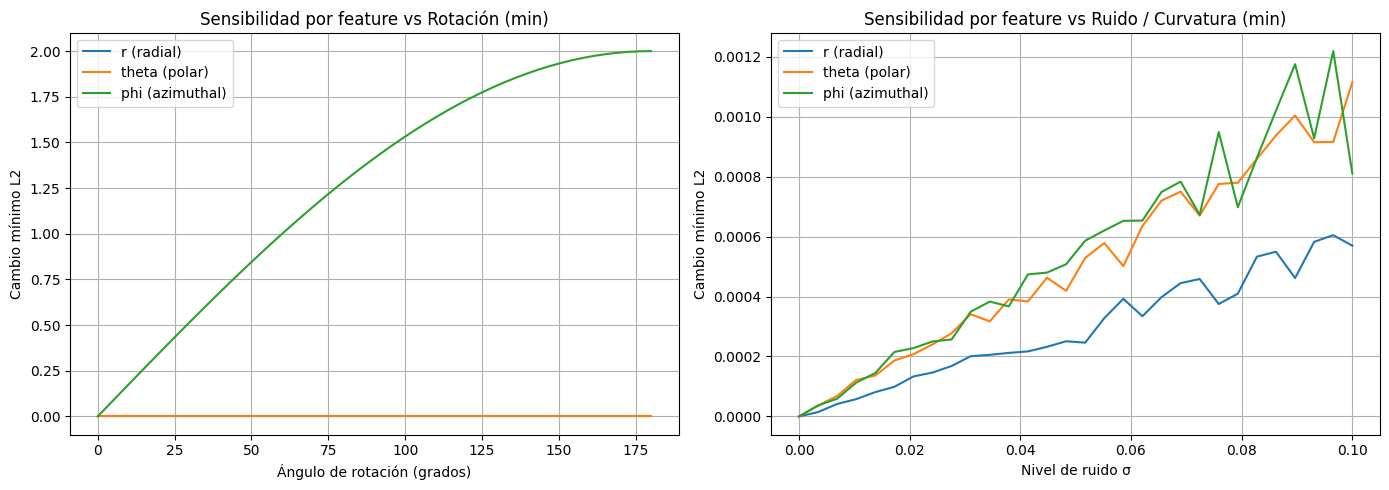

In [30]:
import matplotlib.pyplot as plt

streamlines = streamlines_list  # extend as needed

# ══════════════════════════════════════════════
# PLOT 1: Rotation Z + Noise  (min across streamlines)
# ══════════════════════════════════════════════
angles       = np.linspace(0, np.pi, 50)
noise_levels = np.linspace(0, 0.1, 30)

# Shape: (n_streamlines, n_angles) for each feature
rot_r_all   = np.zeros((len(streamlines), len(angles)))
rot_theta_all = np.zeros((len(streamlines), len(angles)))
rot_phi_all   = np.zeros((len(streamlines), len(angles)))

noise_r_all     = np.zeros((len(streamlines), len(noise_levels)))
noise_theta_all = np.zeros((len(streamlines), len(noise_levels)))
noise_phi_all   = np.zeros((len(streamlines), len(noise_levels)))

for sl_idx, sl in enumerate(streamlines):
    feat_orig = process_single_streamline(sl, global_com, r_min, r_max)

    for i, a in enumerate(angles):
        s_rot   = rotate_z(sl, a)
        com_rot = rotate_z(global_com[None, :], a)[0]
        feat_rot = process_single_streamline(s_rot, com_rot, r_min, r_max)
        r_d, theta_d, phi_d = feature_wise_l2(feat_orig, feat_rot)
        rot_r_all[sl_idx, i]     = r_d
        rot_theta_all[sl_idx, i] = theta_d
        rot_phi_all[sl_idx, i]   = phi_d

    for j, n in enumerate(noise_levels):
        s_noisy    = add_local_noise(sl, noise_std=n)
        feat_noisy = process_single_streamline(s_noisy, global_com, r_min, r_max)
        r_d, theta_d, phi_d = feature_wise_l2(feat_orig, feat_noisy)
        noise_r_all[sl_idx, j]     = r_d
        noise_theta_all[sl_idx, j] = theta_d
        noise_phi_all[sl_idx, j]   = phi_d

# Min across streamlines (axis=0)
r_rot     = rot_r_all.min(axis=0)
theta_rot = rot_theta_all.min(axis=0)
phi_rot   = rot_phi_all.min(axis=0)

r_noise     = noise_r_all.min(axis=0)
theta_noise = noise_theta_all.min(axis=0)
phi_noise   = noise_phi_all.min(axis=0)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(np.degrees(angles), r_rot,     label='r (radial)',      color='tab:blue')
axs[0].plot(np.degrees(angles), theta_rot, label='theta (polar)',   color='tab:orange')
axs[0].plot(np.degrees(angles), phi_rot,   label='phi (azimuthal)', color='tab:green')
axs[0].set_xlabel("Ángulo de rotación (grados)")
axs[0].set_ylabel("Cambio mínimo L2")
axs[0].set_title("Sensibilidad por feature vs Rotación (min)")
axs[0].legend()
axs[0].grid(True)

axs[1].plot(noise_levels, r_noise,     label='r (radial)',      color='tab:blue')
axs[1].plot(noise_levels, theta_noise, label='theta (polar)',   color='tab:orange')
axs[1].plot(noise_levels, phi_noise,   label='phi (azimuthal)', color='tab:green')
axs[1].set_xlabel("Nivel de ruido σ")
axs[1].set_ylabel("Cambio mínimo L2")
axs[1].set_title("Sensibilidad por feature vs Ruido / Curvatura (min)")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

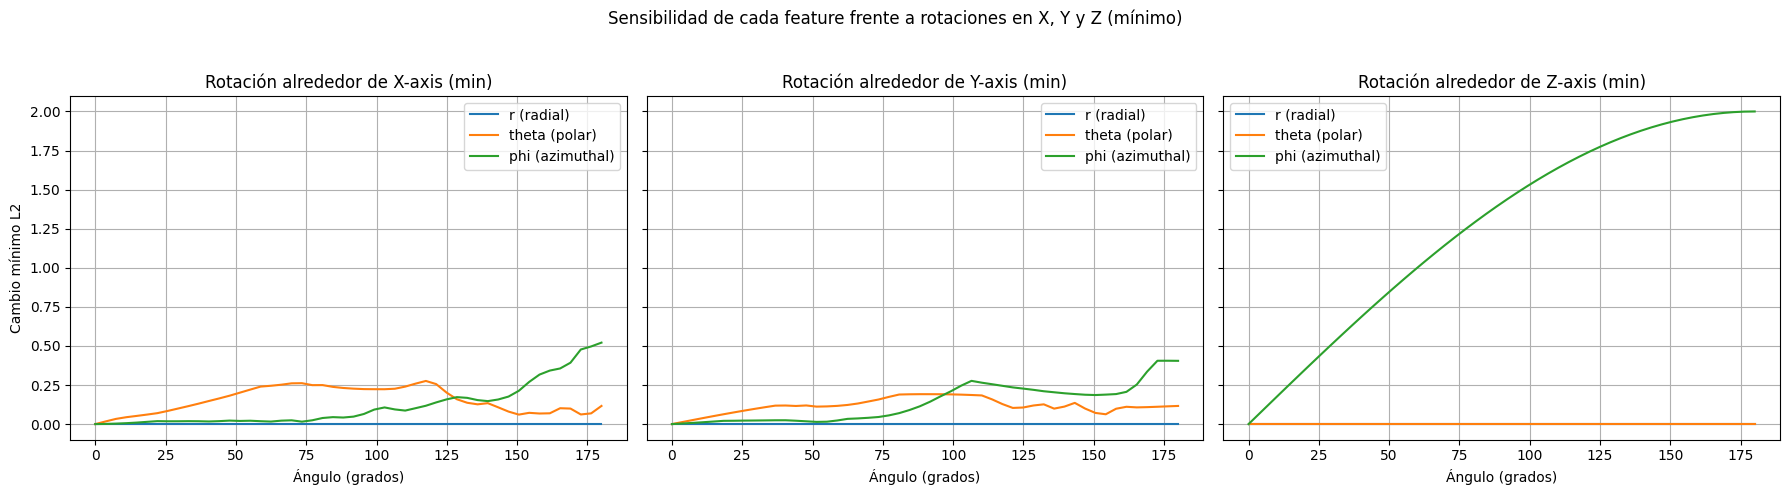

In [31]:
rot_funcs = {'X': rotate_x, 'Y': rotate_y, 'Z': rotate_z}

# Shape: (n_streamlines, n_angles) per axis per feature
results_all = {
    ax: {
        'r':     np.zeros((len(streamlines), len(angles))),
        'theta': np.zeros((len(streamlines), len(angles))),
        'phi':   np.zeros((len(streamlines), len(angles))),
    }
    for ax in ['X', 'Y', 'Z']
}

for sl_idx, sl in enumerate(streamlines):
    feat_orig = process_single_streamline(sl, global_com, r_min, r_max)
    for axis, rot_func in rot_funcs.items():
        for i, a in enumerate(angles):
            s_rot   = rot_func(sl, a)
            com_rot = rot_func(global_com[None, :], a)[0]
            feat_rot = process_single_streamline(s_rot, com_rot, r_min, r_max)
            r_d, theta_d, phi_d = feature_wise_l2(feat_orig, feat_rot)
            results_all[axis]['r'][sl_idx, i]     = r_d
            results_all[axis]['theta'][sl_idx, i] = theta_d
            results_all[axis]['phi'][sl_idx, i]   = phi_d

# Min across streamlines
results_min = {
    ax: (
        results_all[ax]['r'].min(axis=0),
        results_all[ax]['theta'].min(axis=0),
        results_all[ax]['phi'].min(axis=0),
    )
    for ax in ['X', 'Y', 'Z']
}

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, axis in enumerate(['X', 'Y', 'Z']):
    r_vals, theta_vals, phi_vals = results_min[axis]
    axs[i].plot(np.degrees(angles), r_vals,     label='r (radial)',      color='tab:blue')
    axs[i].plot(np.degrees(angles), theta_vals, label='theta (polar)',   color='tab:orange')
    axs[i].plot(np.degrees(angles), phi_vals,   label='phi (azimuthal)', color='tab:green')
    axs[i].set_xlabel("Ángulo (grados)")
    axs[i].set_title(f"Rotación alrededor de {axis}-axis (min)")
    axs[i].grid(True)
    if i == 0:
        axs[i].set_ylabel("Cambio mínimo L2")
    axs[i].legend()

plt.suptitle("Sensibilidad de cada feature frente a rotaciones en X, Y y Z (mínimo)")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

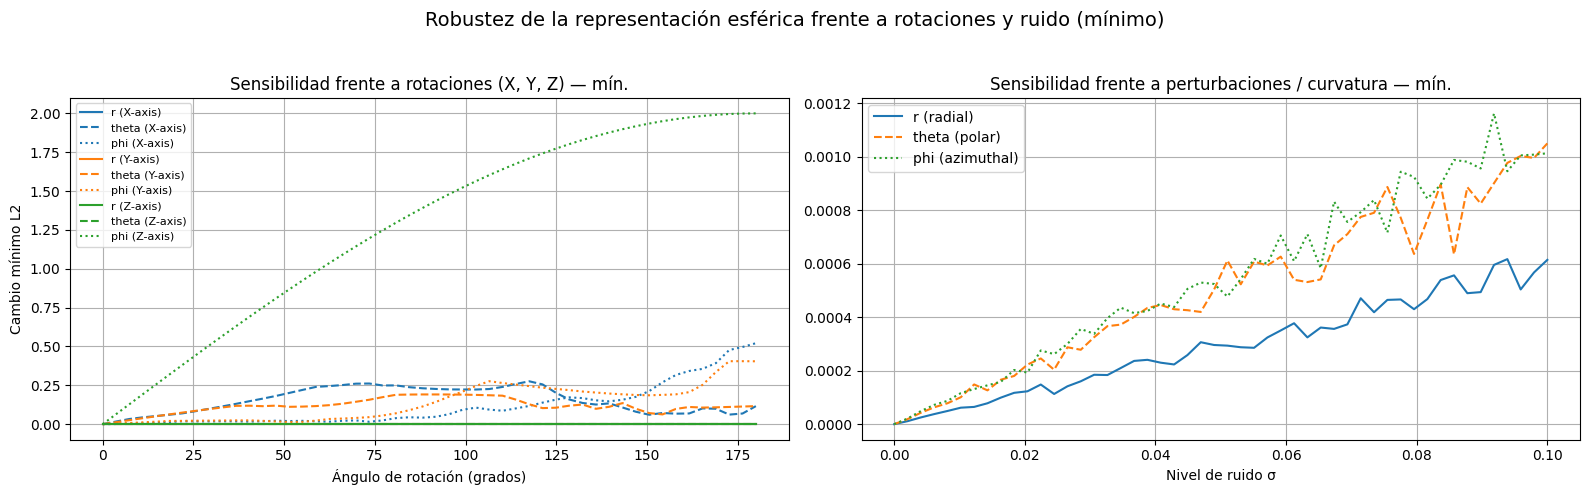

In [32]:
streamlines = streamlines_list  # extend as needed

angles       = np.linspace(0, np.pi, 50)
noise_levels = np.linspace(0, 0.1, 50)
axes         = {'X': rotate_x, 'Y': rotate_y, 'Z': rotate_z}

# ══════════════════════════════════════════════
# ROTACIONES  —  shape (n_streamlines, n_angles)
# ══════════════════════════════════════════════
rotation_arrays = {
    ax: {
        'r':     np.zeros((len(streamlines), len(angles))),
        'theta': np.zeros((len(streamlines), len(angles))),
        'phi':   np.zeros((len(streamlines), len(angles))),
    }
    for ax in axes
}

for sl_idx, sl in enumerate(streamlines):
    feat_orig = process_single_streamline(sl, global_com, r_min, r_max)
    for axis, rot_func in axes.items():
        for i, a in enumerate(angles):
            s_rot    = rot_func(sl, a)
            com_rot  = rot_func(global_com[None, :], a)[0]
            feat_rot = process_single_streamline(s_rot, com_rot, r_min, r_max)
            r_d, theta_d, phi_d = feature_wise_l2(feat_orig, feat_rot)
            rotation_arrays[axis]['r'][sl_idx, i]     = r_d
            rotation_arrays[axis]['theta'][sl_idx, i] = theta_d
            rotation_arrays[axis]['phi'][sl_idx, i]   = phi_d

# Min across streamlines → (n_angles,)
rotation_results = {
    ax: (
        rotation_arrays[ax]['r'].min(axis=0),
        rotation_arrays[ax]['theta'].min(axis=0),
        rotation_arrays[ax]['phi'].min(axis=0),
    )
    for ax in axes
}

# ══════════════════════════════════════════════
# RUIDO / CURVATURA  —  shape (n_streamlines, n_noise_levels)
# ══════════════════════════════════════════════
noise_r_all     = np.zeros((len(streamlines), len(noise_levels)))
noise_theta_all = np.zeros((len(streamlines), len(noise_levels)))
noise_phi_all   = np.zeros((len(streamlines), len(noise_levels)))

for sl_idx, sl in enumerate(streamlines):
    feat_orig = process_single_streamline(sl, global_com, r_min, r_max)
    for j, n in enumerate(noise_levels):
        s_noisy    = add_local_noise(sl, noise_std=n)
        feat_noisy = process_single_streamline(s_noisy, global_com, r_min, r_max)
        r_d, theta_d, phi_d = feature_wise_l2(feat_orig, feat_noisy)
        noise_r_all[sl_idx, j]     = r_d
        noise_theta_all[sl_idx, j] = theta_d
        noise_phi_all[sl_idx, j]   = phi_d

# Min across streamlines → (n_noise_levels,)
r_noise     = noise_r_all.min(axis=0)
theta_noise = noise_theta_all.min(axis=0)
phi_noise   = noise_phi_all.min(axis=0)

# ══════════════════════════════════════════════
# PLOT
# ══════════════════════════════════════════════
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

for axis, color in zip(['X', 'Y', 'Z'], ['tab:blue', 'tab:orange', 'tab:green']):
    r_vals, theta_vals, phi_vals = rotation_results[axis]
    axs[0].plot(np.degrees(angles), r_vals,     label=f'r ({axis}-axis)',     color=color, linestyle='-')
    axs[0].plot(np.degrees(angles), theta_vals, label=f'theta ({axis}-axis)', color=color, linestyle='--')
    axs[0].plot(np.degrees(angles), phi_vals,   label=f'phi ({axis}-axis)',   color=color, linestyle=':')

axs[0].set_xlabel("Ángulo de rotación (grados)")
axs[0].set_ylabel("Cambio mínimo L2")
axs[0].set_title("Sensibilidad frente a rotaciones (X, Y, Z) — mín.")
axs[0].grid(True)
axs[0].legend(fontsize=8)

axs[1].plot(noise_levels, r_noise,     label='r (radial)',      color='tab:blue',   linestyle='-')
axs[1].plot(noise_levels, theta_noise, label='theta (polar)',   color='tab:orange', linestyle='--')
axs[1].plot(noise_levels, phi_noise,   label='phi (azimuthal)', color='tab:green',  linestyle=':')
axs[1].set_xlabel("Nivel de ruido σ")
axs[1].set_title("Sensibilidad frente a perturbaciones / curvatura — mín.")
axs[1].grid(True)
axs[1].legend(fontsize=10)

plt.suptitle("Robustez de la representación esférica frente a rotaciones y ruido (mínimo)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()